# Student Performance Analysis

## Executive Summary

This project analyzes student academic performance data to identify patterns and factors influencing students' scores. The analysis focuses on score distribution, gender-based performance, the impact of test preparation, parental education influence, and correlations between subjects.

The score distribution analysis shows that most students achieve moderate academic performance, with the majority of scores concentrated around the middle range. This indicates a relatively balanced distribution of academic outcomes among students.

Gender-based analysis reveals that the difference in average performance between male and female students is relatively small, suggesting that gender does not significantly impact overall academic results in this dataset.

The analysis of test preparation courses indicates that students who completed the preparation program generally achieve higher scores compared to those who did not participate. This highlights the importance of structured preparation in improving academic performance.

Parental education level also shows an influence on student outcomes. Students whose parents have higher educational qualifications tend to achieve better academic results, suggesting that educational background may contribute to the learning environment and academic support available to students.

Correlation analysis reveals strong positive relationships between subjects. In particular, reading and writing scores show a very strong correlation (0.95), indicating that students who perform well in reading are also likely to perform well in writing. Math scores also demonstrate strong relationships with both reading and writing.

Overall, the analysis highlights the importance of preparation programs, academic support, and foundational skills in improving student performance. Educational institutions can use these insights to design targeted learning strategies and provide additional support for students who require academic assistance.

Business Impact:
Educational institutions can implement targeted interventions,
expand preparation programs, and provide support to weak-performing students.

## Objective
To analyze academic performance data to understand the factors influencing student scores and identify patterns that impact overall academic outcomes.

## Key Questions
- What is the overall performance distribution?
- Does gender influence performance?
- Does test preparation improve scores?
- How does parental education affect student performance?
- What correlations exist between subjects?

## Tools and Technologies Used

The analysis was conducted using the following tools:

- Python
- Pandas for data manipulation
- NumPy for numerical analysis
- Matplotlib for visualization
- Seaborn for statistical visualization
- Jupyter Notebook

## Dataset Source and Columns

The dataset used for this project is the **Student Performance Dataset**, which contains information about students’ academic scores and demographic characteristics.

Source: Kaggle – Students Performance in Exams Dataset

The dataset contains the following columns:

- Gender – Student gender
- Race/ethnicity – Ethnic group category
- Parental level of education – Education level of parents
- Lunch – Type of lunch received
- Test preparation course – Completed or not completed
- Math score – Score obtained in mathematics
- Reading score – Score obtained in reading
- Writing score – Score obtained in writing

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

In [2]:
#Load Datset
df = pd.read_csv("StudentsPerformance.csv")

print("Shape:", df.shape)
df.head()

Shape: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
#Dataset Overview
print("\nDuplicate Rows:", df.duplicated().sum())

print("\nMissing Values:\n", df.isnull().sum())

print("\nNegative Score Check:")
print((df[["math score","reading score","writing score"]] < 0).sum())


Duplicate Rows: 0

Missing Values:
 gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Negative Score Check:
math score       0
reading score    0
writing score    0
dtype: int64


In [4]:
#Feature Engineering
df["Total_Score"] = df["math score"] + df["reading score"] + df["writing score"]
df["Average_Score"] = df["Total_Score"] / 3

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total_Score,Average_Score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


## Data Preparation and Feature Engineering

Before performing deeper analysis, additional features were created to support better insights.

An **Average Score** column was generated using math, reading, and writing scores to represent the overall academic performance of each student.

Additionally, a **Pass/Fail classification** was created to categorize students based on their academic performance threshold.

These engineered features help simplify the analysis and make interpretation of results easier.

In [5]:
# 5. Statistical Summary
print("\nMean Scores:\n", df[["math score","reading score","writing score"]].mean())

print("\nMedian Scores:\n", df[["math score","reading score","writing score"]].median())

print("\nVariance:\n", df[["math score","reading score","writing score"]].var())

print("\nStandard Deviation:\n", df[["math score","reading score","writing score"]].std())


Mean Scores:
 math score       66.089
reading score    69.169
writing score    68.054
dtype: float64

Median Scores:
 math score       66.0
reading score    70.0
writing score    69.0
dtype: float64

Variance:
 math score       229.918998
reading score    213.165605
writing score    230.907992
dtype: float64

Standard Deviation:
 math score       15.163080
reading score    14.600192
writing score    15.195657
dtype: float64


## Descriptive Statistics Analysis of Student Scores

This analysis summarizes the central tendency and variability of student scores in **Math, Reading, and Writing**.

### Central Tendency
The **mean scores** are:
- Math: 66.09
- Reading: 69.17
- Writing: 68.05

The **median scores** are:
- Math: 66
- Reading: 70
- Writing: 69

The close values between the **mean and median** indicate that the score distribution in each subject is relatively balanced with minimal skewness. Students tend to perform slightly better in **Reading and Writing compared to Math**.

### Variability
The **variance values** (Math: 229.92, Reading: 213.17, Writing: 230.91) and **standard deviations** (around 14–15) show that the spread of scores is similar across all three subjects.

This indicates that while average performance differs slightly between subjects, the **variation in student performance remains consistent**.

### Key Insight
Overall, students demonstrate **stronger performance in Reading**, followed closely by **Writing**, while **Math scores are comparatively lower**. However, the variability across subjects suggests that student performance patterns are fairly consistent.

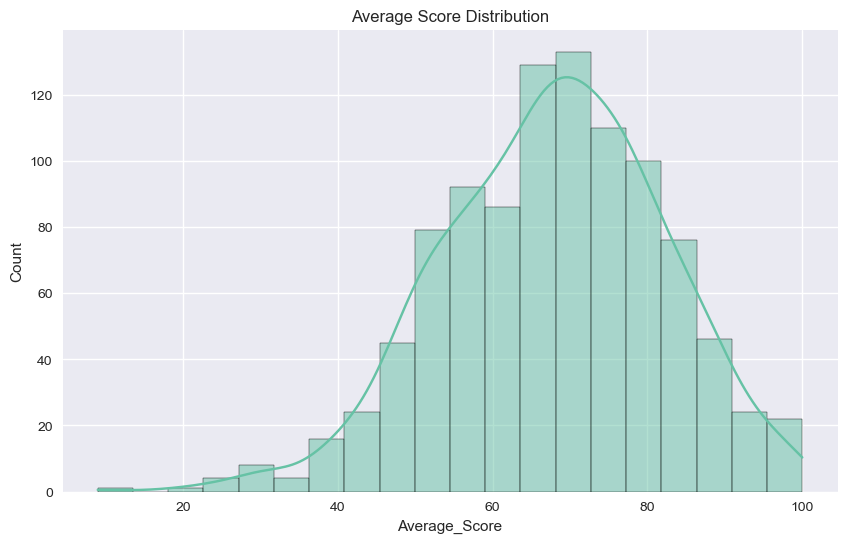

In [6]:
#Score Distribution
plt.figure(figsize=(10,6))
sns.histplot(df["Average_Score"], bins=20, kde=True)
plt.title("Average Score Distribution")
plt.show()

# Score Distribution

The histogram shows the distribution of the average scores across all students.

Most students fall within a moderate score range, indicating that the majority of students achieve average academic performance.

The distribution appears approximately normal, meaning extreme high and low scores are relatively fewer compared to mid-range scores.

This suggests that overall academic performance is relatively balanced across the student population.


Average Score by Gender:
gender
female    69.569498
male      65.837483
Name: Average_Score, dtype: float64


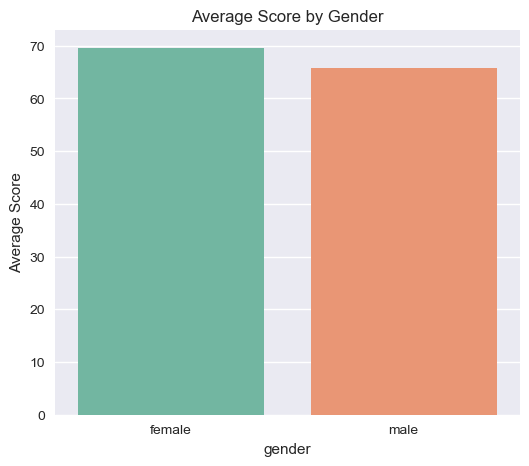

In [7]:
#Gender Comparison
gender_avg = df.groupby("gender")["Average_Score"].mean()
print("\nAverage Score by Gender:")
print(gender_avg)

plt.figure(figsize=(6,5))
sns.barplot(x=gender_avg.index, y=gender_avg.values)
plt.title("Average Score by Gender")
plt.ylabel("Average Score")
plt.show()

## Gender-wise Performance Analysis

The bar chart compares the average scores of male and female students.

The visualization highlights differences in academic performance between genders and helps identify whether gender influences student outcomes.

From the analysis, the average performance between genders is relatively close, indicating that academic performance is fairly balanced between male and female students.

This suggests that gender alone is not a major determining factor for academic success in this dataset.


Average Score by Test Preparation:
 test preparation course
completed    72.669460
none         65.038941
Name: Average_Score, dtype: float64

Improvement due to Test Preparation: 7.63


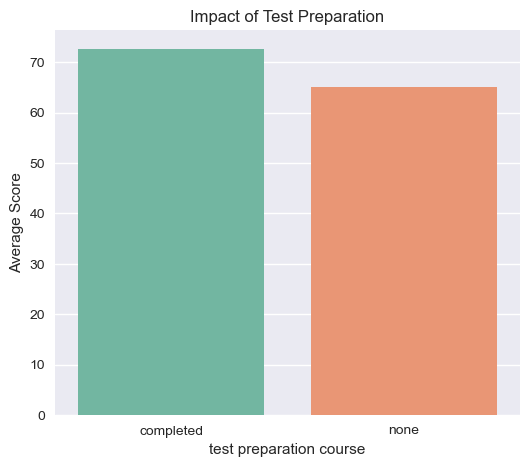

In [8]:
#Test Preparation Impact
prep_avg = df.groupby("test preparation course")["Average_Score"].mean()

print("\nAverage Score by Test Preparation:\n", prep_avg)

improvement = prep_avg["completed"] - prep_avg["none"]
print("\nImprovement due to Test Preparation:", round(improvement,2))

plt.figure(figsize=(6,5))
sns.barplot(x=prep_avg.index, y=prep_avg.values)
plt.title("Impact of Test Preparation")
plt.ylabel("Average Score")
plt.show()

## Impact of Test Preparation
The analysis compares the academic performance of students who completed the test preparation course and those who did not.

Students who completed the test preparation program show higher average scores compared to those who did not participate.

This indicates that structured preparation programs positively influence student performance.

Providing additional preparation opportunities can help improve overall academic outcomes.


Average Score by Parental Education:
parental level of education
high school           63.096939
some high school      65.108007
some college          68.476401
associate's degree    69.569069
bachelor's degree     71.923729
master's degree       73.598870
Name: Average_Score, dtype: float64


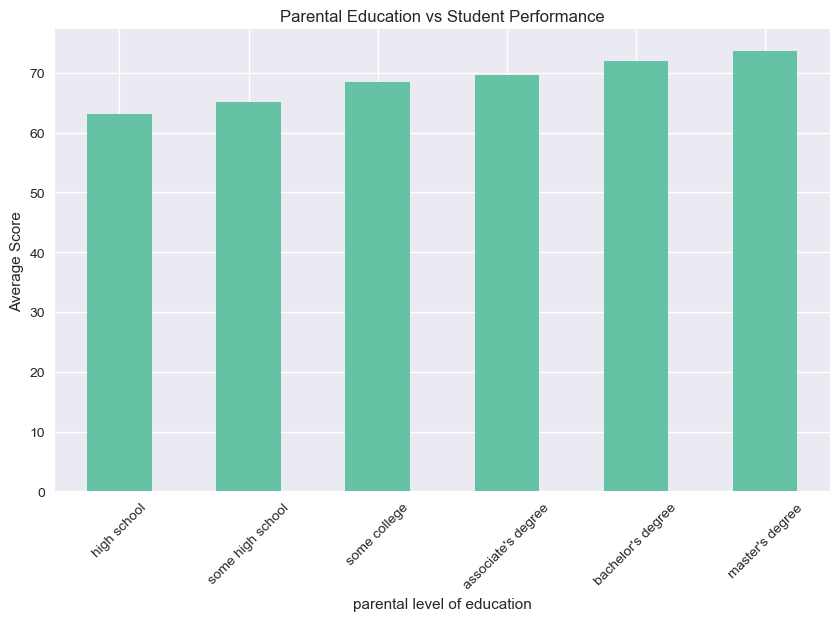

In [9]:
#Parental Education Impact
parent_avg = df.groupby("parental level of education")["Average_Score"].mean().sort_values()
print("\nAverage Score by Parental Education:")
print(parent_avg)

plt.figure(figsize=(10,6))
parent_avg.plot(kind="bar")
plt.title("Parental Education vs Student Performance")
plt.ylabel("Average Score")
plt.xticks(rotation=45)
plt.show()

## Parental Education Impact

This analysis examines how parental education level influences student academic performance.

Students whose parents have higher educational qualifications tend to achieve higher average scores.

The results show that students with parents holding a **master’s degree achieve the highest average performance**, while students whose parents completed only **high school show the lowest average scores**.

This suggests that parental educational background may influence the learning environment and academic support available to students.


Correlation between Subjects:
                math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000


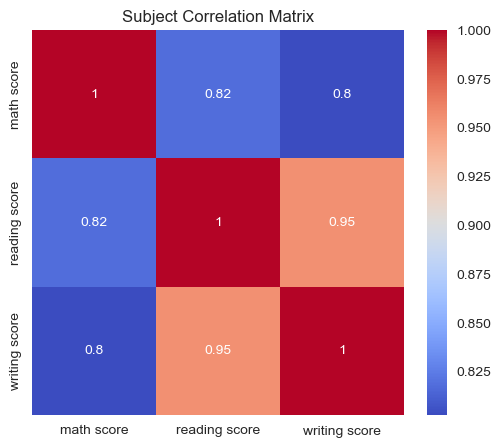

In [10]:
#Correlation Matrix
corr_matrix = df[["math score","reading score","writing score"]].corr()

print("\nCorrelation between Subjects:\n", corr_matrix)

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Subject Correlation Matrix")
plt.show()

## Correlation Analysis

The correlation matrix shows the relationship between scores in different subjects.

The results indicate strong positive correlations between all subjects.

The correlation between **reading and writing scores is the strongest (0.95)**, suggesting that students who perform well in reading also tend to perform well in writing.

Similarly, math scores show strong positive relationships with both reading (0.82) and writing (0.80).

This indicates that strong academic skills often translate across multiple subjects.


Pass/Fail Counts:
Pass_Status
Pass    970
Fail     30
Name: count, dtype: int64


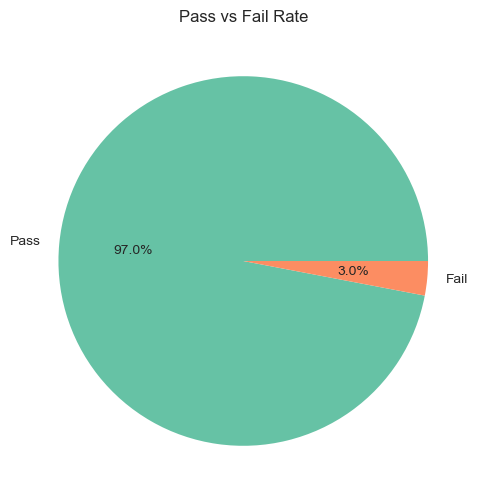

In [11]:
#Pass/Fail Classification
df["Pass_Status"] = np.where(df["Average_Score"] >= 40, "Pass", "Fail")

pass_counts = df["Pass_Status"].value_counts()
print("\nPass/Fail Counts:")
print(pass_counts)

plt.figure(figsize=(6,6))
pass_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Pass vs Fail Rate")
plt.ylabel("")
plt.show()

## Pass/Fail Classification

Students were classified into Pass or Fail categories based on their average scores.

Students with an average score of **40 or above** were categorized as Pass, while those below this threshold were categorized as Fail.

In above Pie chart indicates 97% (970) students are pass and 3% (30) students are fail

This classification helps evaluate overall academic success and identify students who may require additional academic assistance.


Performance Segmentation:
 Performance_Level
Good         517
Average      255
Excellent    198
Weak          30
Name: count, dtype: int64

Performance Segmentation Percentage:
 Performance_Level
Good         51.7
Average      25.5
Excellent    19.8
Weak          3.0
Name: proportion, dtype: float64


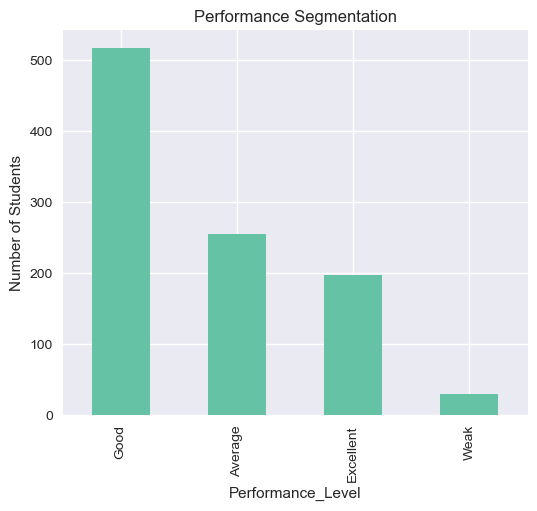

In [12]:
# Performance Segmentation
def performance_level(score):
    if score >= 80:
        return "Excellent"
    elif score >= 60:
        return "Good"
    elif score >= 40:
        return "Average"
    else:
        return "Weak"

df["Performance_Level"] = df["Average_Score"].apply(performance_level)

performance_counts = df["Performance_Level"].value_counts()

print("\nPerformance Segmentation:\n", performance_counts)

performance_percent = df["Performance_Level"].value_counts(normalize=True) * 100

print("\nPerformance Segmentation Percentage:\n", performance_percent)

plt.figure(figsize=(6,5))
performance_counts.plot(kind="bar")
plt.title("Performance Segmentation")
plt.ylabel("Number of Students")
plt.show()

## Performance Segmentation

Students were categorized into four performance levels based on their average scores:

- Excellent
- Good
- Average
- Weak

This segmentation helps identify students who may require additional academic support.

Most students fall into the **Good and Average categories**, indicating moderate academic performance for the majority of students.

The identification of weak-performing students allows educators to provide targeted support and improve learning outcomes..

In [13]:
#Additional Statistical Insight
print("\nHighest Performing Parental Education Group:")
print(parent_avg.idxmax(), "with average score:", round(parent_avg.max(),2))

print("\nLowest Performing Parental Education Group:")
print(parent_avg.idxmin(), "with average score:", round(parent_avg.min(),2))


Highest Performing Parental Education Group:
master's degree with average score: 73.6

Lowest Performing Parental Education Group:
high school with average score: 63.1


## Key Insights

1. The distribution of average scores indicates that most students perform within a moderate academic range.

2. Gender differences in academic performance are relatively small, suggesting that performance levels are similar across male and female students.

3. Students who completed the test preparation course demonstrate higher average scores, highlighting the importance of structured academic preparation.

4. Parental education level influences academic outcomes, with students whose parents hold higher degrees achieving better performance.

5. Strong positive correlations exist between subjects, particularly between reading and writing scores (0.95), indicating that students who excel in one subject often perform well in others.

6. Performance segmentation reveals that most students fall within the Average and Good categories, while a smaller group of students require additional academic support.

## Recommendations

1. Educational institutions should expand **test preparation programs** to help students improve their academic performance.

2. Additional academic support should be provided to students categorized as **weak performers** to improve their learning outcomes.

3. Schools can implement **early performance monitoring systems** to identify struggling students at an early stage.

4. Encouraging structured study practices and learning support programs can help improve performance across multiple subjects.

5. Educators should focus on strengthening **core literacy skills**, as reading and writing performance strongly influence overall academic success.

## Conclusion
The student performance analysis explored how demographic and educational factors influence academic outcomes.

The results show that test preparation courses and parental education levels have noticeable effects on student performance. Additionally, strong correlations were observed between reading and writing scores, indicating consistent academic abilities across related subjects.

These insights can help educators design targeted interventions and support strategies to improve student academic success.